# 在 Cell 上放置和采样突触

本教程只回答三个问题：

1. 如何在 `Cell` 的指定位置创建突触；
2. 如何用 `SynapseView` 查询和修改这些突触；
3. 如何从连续 morphology region 中随机采样突触位置。

这里不创建 `Connection`，也不涉及 `Network`、事件源、`weight`、`delay` 或仿真调度。

In [1]:
import os
from pathlib import Path
import warnings

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import brainunit as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import braincell
from braincell import mech
from braincell.filter import at, branch_in, metric, sample

## 1. 创建一个最小的 postsynaptic Cell

先用一个 soma 和两条带 3D 坐标的 dendrite 构造三成员 population。`CVPerBranchList((1, 2, 3))` 分别把三条 branch 分成 1、2、3 个 CV。这个 Cell 只提供突触放置所需的 morphology 和 CV；本教程不运行膜电位动力学，因此不需要 paint ion channel。

In [2]:
soma = braincell.Branch.from_points(
    points=np.asarray([[-10.0, 0.0, 0.0], [10.0, 0.0, 0.0]]) * u.um,
    radii=np.asarray([10.0, 10.0]) * u.um, type="soma",
)
dend_a = braincell.Branch.from_points(
    points=np.asarray([[0.0, 0.0, 0.0], [0.0, 120.0, 0.0]]) * u.um,
    radii=np.asarray([2.0, 1.0]) * u.um, type="basal_dendrite",
)
dend_b = braincell.Branch.from_points(
    points=np.asarray([[0.0, 0.0, 0.0], [-120.0, -120.0, 60.0]]) * u.um,
    radii=np.asarray([2.5, 0.8]) * u.um, type="apical_dendrite",
)

morphology = braincell.Morphology.from_root(soma, name="soma")
morphology.soma.attach(dend_a, name="dend_a", parent_x=0.5)
morphology.soma.attach(dend_b, name="dend_b", parent_x=0.5)

cell = braincell.Cell(
    morphology,
    cv_policy=braincell.CVPerBranchList((1, 2, 3)),
    pop_size=(3,),
    name="post",
)
cell

Cell(root='soma', n_branches=3, n_paint_rules=1, n_place_rules=0, initialized=False)

## 2. `place()` 的位置与参数广播

`Synapse` 声明 postsynaptic dynamics 的类型和参数。`ExpSyn` 的 `tau`、`e` 属于 Synapse；事件携带的 `weight`、`delay` 属于 Connection，因此不会出现在这里。

记本次选中的 cell 数为 $P$，每个 cell 的等长位置数为 $L$，ragged 情况下第 $i$ 个 cell 的位置数为 $L_i$。位置的广播规则是：

| `locations` 输入 | 对齐语义 | 每个 mechanism 产生的 logical rows |
|---|---|---:|
| 一个 `LocsetExpr` / `LocsetMask`，长度 $L$ | 同一组位置广播给所有选中 cell | $P L$ |
| `LocsetBatch`，shape `(P, L)` | 第 $i$ 行位置只属于第 $i$ 个 cell | $P L$ |
| 长度为 $P$ 的 locset sequence | 每个 cell 独立一行，允许空行和不同 $L_i$ | $\sum_i L_i$ |
| `place(locations, mech1, ..., mechM)` | 每个位置分别创建每个 mechanism | 上述行数再乘 $M$ |

位置为规则确定了目标 `(cell, location)` 行；每个 Synapse 参数再广播到这些行：

| 参数 shape | rectangular `(P, L)` | ragged `(L_0, ..., L_{P-1})` |
|---|---|---|
| scalar | 所有行共用 | 所有行共用 |
| `(L,)` | 每个 cell 重复同一组 location 值 | 仅当各行等长时可用 |
| `(P, 1)` | 每个 cell 一个值，再沿 location 广播 | 每个 cell 一个值，再沿自己的 $L_i$ 广播 |
| `(P, L)` | 逐 cell、逐 location 指定 | 不适用 |
| `(P * L,)` | cell-major 扁平值 | 不适用 |
| ragged sequence | 可以使用，但通常没有必要 | 每行是 scalar 或 shape `(L_i,)` |
| `(sum(L_i),)` | 等价于 `(P * L,)` | cell-major 扁平值 |

这里的 $P$ 是当前 `CellView` 选中的数量；例如 `cell[[2, 0]]` 的 $P=2$。最终 logical row 顺序始终是 cell-major。下面三个调用分别演示 shared、rectangular 和 ragged 放置。

In [3]:
# 1. 一个长度 L=2 的 locset 广播到 P=3 个 cell；tau 的 (L,) 也沿 cell 重复。
fast_ampa = mech.Synapse(
    "ExpSyn", name="fast_ampa",
    tau=np.asarray([1.0, 3.0]) * u.ms, e=0.0 * u.mV,
)
shared_locations = at("dend_a", 0.25) + at("dend_b", 0.50)
cell.place(shared_locations, fast_ampa)

# 2. LocsetBatch 的三行与三个 cell 对齐；tau 的 (P, 1) 沿各行广播。
rectangular_locations = cell.cv_midpoints[np.asarray([[1, 3], [2, 4], [3, 5]])]
slow_ampa = mech.Synapse(
    "ExpSyn", name="slow_ampa",
    tau=np.asarray([[4.0], [5.0], [6.0]]) * u.ms, e=-5.0 * u.mV,
)
cell.place(rectangular_locations, slow_ampa)

# 3. 每个 cell 分别获得 1、2、3 个位置；tau2 使用同形的 ragged 参数。
ragged_locations = (
    at("dend_a", 0.10),
    at("dend_a", 0.60) + at("dend_b", 0.20),
    at("dend_b", 0.25) + at("dend_b", 0.50) + at("dend_b", 0.75),
)
nmda = mech.Synapse(
    "Exp2Syn", name="nmda", tau1=0.5 * u.ms,
    tau2=(
        np.asarray([7.0]) * u.ms,
        np.asarray([8.0, 9.0]) * u.ms,
        np.asarray([10.0, 11.0, 12.0]) * u.ms,
    ),
    e=0.0 * u.mV,
)
cell.place(ragged_locations, nmda)

assert len(cell.synapses) == 18
pd.crosstab(
    [cell.synapses.synapse_type, cell.synapses.name],
    cell.synapses.population_index,
    rownames=["type", "name"], colnames=["cell"],
)

cell               0  1  2
type    name              
Exp2Syn nmda       1  2  3
ExpSyn  fast_ampa  2  2  2
        slow_ampa  2  2  2

## 3. 用 `SynapseView` 逐层查看和修改

所有入口都返回同一种 `SynapseView`；继续筛选只是组合 logical IDs，不复制参数或状态数组。`synapse_type` 决定 runtime SoA 分组，`name` 只负责用户语义分组。同一个 name 可以由多次 `place()` 扩展，但不能跨不同 type。

| 查询 | 层次与结果 |
|---|---|
| `cell.synapses` | 当前 Cell 的全部 logical synapse rows |
| `cell[1].synapses` | 先限定 population member |
| `.by_type("ExpSyn")` | 按 runtime model type 筛选 |
| `["fast_ampa"]` / `.by_name(...)` | 按用户声明的 name 筛选 |
| `[fast_ampa]` | 按原始 `Synapse` 对象 identity 筛选 |
| `[0]`、`[2:5]`、整数或布尔数组 | 按当前 view 的 logical row 顺序继续切片 |
| `.tau` / `.get("tau")` | 读取 homogeneous-type view 的模型参数 |
| `.set(tau=...)` | 按当前 view 顺序修改命中的参数行 |

包含多个 type 的 view 仍可查看公共列，但不能直接读取 `.tau` 等 model-specific 参数；需要先按 type 或 name 收窄。

In [4]:
query_examples = pd.DataFrame({
    "query": [
        "cell.synapses",
        "cell[1].synapses",
        "cell.synapses.by_type('ExpSyn')",
        "cell.synapses['fast_ampa']",
        "cell.synapses[fast_ampa]",
    ],
    "rows": [
        len(cell.synapses),
        len(cell[1].synapses),
        len(cell.synapses.by_type("ExpSyn")),
        len(cell.synapses["fast_ampa"]),
        len(cell.synapses[fast_ampa]),
    ],
})
display(query_examples)

selected = cell[1].synapses["fast_ampa"]
selected.set(tau=np.asarray([2.0, 4.0]) * u.ms)
pd.DataFrame({"id": selected.id, "tau_ms": selected.tau.to_decimal(u.ms)})

,query,rows
0,cell.synapses,18
1,cell[1].synapses,6
2,cell.synapses.by_type('ExpSyn'),12
3,cell.synapses['fast_ampa'],6
4,cell.synapses[fast_ampa],6


,id,tau_ms
0,1,2.0
1,4,4.0


每一行都是一个独立 logical synapse。`id` 是稳定 logical ID，不等于当前 view 的行号；`placement_id` 指向原始放置行。`branch_x` 保留连续位置，`cv_id` 表示该位置映射到的控制体积。即使位置、type、name 和参数完全相同，logical rows 也不会自动合并。

In [5]:
synapses = cell.synapses
pd.DataFrame({
    "id": synapses.id,
    "cell": synapses.population_index,
    "placement_id": synapses.placement_id,
    "type": synapses.synapse_type,
    "name": synapses.name,
    "branch": [morphology.branches[i].name for i in synapses.branch_id],
    "branch_x": synapses.branch_x,
    "cv_id": synapses.cv_id,
})

,id,cell,placement_id,type,name,branch,branch_x,cv_id
0,0,0,0,ExpSyn,fast_ampa,dend_a,0.250000,1
1,3,0,1,ExpSyn,fast_ampa,dend_b,0.500000,4
2,6,0,2,ExpSyn,slow_ampa,dend_a,0.250000,1
3,9,0,3,ExpSyn,slow_ampa,dend_b,0.166667,3
4,24,0,8,Exp2Syn,nmda,dend_a,0.100000,1
5,1,1,0,ExpSyn,fast_ampa,dend_a,0.250000,1
6,4,1,1,ExpSyn,fast_ampa,dend_b,0.500000,4
7,13,1,4,ExpSyn,slow_ampa,dend_a,0.750000,2
8,16,1,5,ExpSyn,slow_ampa,dend_b,0.500000,4
9,28,1,9,Exp2Syn,nmda,dend_a,0.600000,2


## 4. 在真实 GoC morphology 上采样

下面从仓库导入一棵真实 Golgi cell morphology：它包含 1 条 soma、151 条 dendrite 和 75 条 axon。

In [6]:
repo_root = Path(braincell.__file__).resolve().parent.parent
goc_path = repo_root / "data/cerebellum/goc_ma2020/morphology/GoC.asc"
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", message=r"from_points\(\) produced .* zero-length segment",
    )
    goc_morphology = braincell.Morphology.from_asc(goc_path)

goc = braincell.Cell(
    goc_morphology,
    cv_policy=braincell.CVPerBranch(),
    name="goc",
)
pd.Series({"branches": len(goc_morphology.branches), "CVs": goc.n_cv})

branches    227
CVs         227
dtype: int64

## 5. 从连续 dendrite region 采样并放置

`sample()` 返回延迟解析的 `LocsetExpr`：它保存 region、样本数、seed 和概率测度，而不是立即把位置变成 CV。传给 `place()` 后，BrainCell 才根据具体 morphology 生成连续 `(branch_id, branch_x)` 并映射到 CV。

这里用 `measure="area"`，因此膜面积更大的 morphology 区间拥有更高的基础采样概率。固定 seed 使结果可以复现。

In [7]:
dendrites = branch_in("type", "dendrite")
sampled_locations = sample(
    dendrites, number=50, seed=7, measure="area",
)
sampled_ampa = mech.Synapse(
    "ExpSyn", name="sampled_ampa", tau=2.0 * u.ms, e=0.0 * u.mV,
)
goc.place(sampled_locations, sampled_ampa)
goc.synapses["sampled_ampa"]

SynapseView(target=Cell(name='goc'), size=50, synapse_type=ExpSyn, names={'sampled_ampa': 50}, parameters=('e', 'tau'))

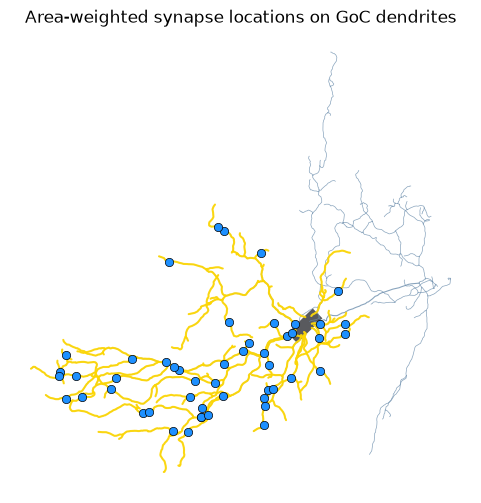

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
_ = goc_morphology.vis2d(
    layout="projected", shape="line",
    region=dendrites.evaluate(goc_morphology),
    locset=sampled_locations.evaluate(goc_morphology), ax=ax, show=False,
)
ax.set_aspect("equal", adjustable="box")
_ = ax.set_title("Area-weighted synapse locations on GoC dendrites")

`CVPerBranch()` 为每条 branch 创建一个 CV。多个连续位置可能映射到同一个 CV，但它们的 `branch_x` 和 logical synapse ID 不会合并。

In [9]:
sampled = goc.synapses["sampled_ampa"]
sampled_table = pd.DataFrame({
    "id": sampled.id,
    "branch": [goc_morphology.branches[i].name for i in sampled.branch_id],
    "branch_x": sampled.branch_x,
    "cv_id": sampled.cv_id,
})
display(sampled_table.head(10))
pd.Series({
    "logical synapses": len(sampled),
    "occupied CVs": len(np.unique(sampled.cv_id)),
})

,id,branch,branch_x,cv_id
0,0,dendrite_102,0.036629,178
1,1,dendrite_123,0.711468,199
2,2,dendrite_58,0.667962,134
3,3,dendrite_62,0.302126,138
4,4,dendrite_34,0.378793,110
5,5,dendrite_78,0.182895,154
6,6,dendrite_118,0.117174,194
7,7,dendrite_114,0.168360,190
8,8,dendrite_145,0.438909,221
9,9,dendrite_12,0.897179,88


logical synapses    50
occupied CVs        41
dtype: int64

## 6. measure 与 density 分别控制什么

采样不是对 branch 编号做均匀抽样，而是在所选 region 上定义连续概率密度：

  $$
  p(b,x)
  =
  \frac{\rho(b,x)\,J_{\mathrm{measure}}(b,x)}
  {\displaystyle\sum_k\int_{R_k}\rho(k,s)\,J_{\mathrm{measure}}(k,s)\,ds}.
  $$

  其中，$b$ 是 branch，$x\in[0,1]$ 是 `branch_x`，$\rho$ 是 `density`。对于长度采样，
  $J_{\mathrm{length}}=L_b$；对于面积采样，$J_{\mathrm{area}}$ 是该位置对应的膜面积微元。因此可以简单理解为：

  $$
  \text{sampling probability}\propto\text{density}\times\text{geometry measure}.
  $$

`ctx` 表示积分器当前考察的连续候选点 $(b,x)$；`metric` 从这个点读取一个几何量；`density(ctx)` 再将一个或多个几何量组合为有限、非负、无量纲的采样权重。换言之，`metric.path_distance_from_soma` 本身不是 density。

| 连续候选点信息 | 写法 | 返回值 |
|---|---|---|
| branch 编号 | `ctx.branch_id` | Python `int` |
| branch 名称 | `ctx.branch_name` | `str` 或 `None` |
| branch 类型 | `ctx.branch_type` | `str` 或 `None` |
| branch 内位置 | `metric.branch_x(ctx)` | $x\in[0,1]$ |
| 局部半径 | `metric.radius(ctx)` | 长度 quantity |
| 到 soma 的树路径距离 | `metric.path_distance_from_soma(ctx)` | 长度 quantity |
| 三维坐标 | `metric.position(ctx)` | shape `(3,)` 的长度 quantity |

这里的半径、距离和坐标都在连续的 `branch_x` 上插值，不是读取 CV 中点。$d_{\mathrm{soma}}(b,x)$ 是该点到所有 soma branches 所组成区域的最短树路径；soma 上恒为 0。若 morphology 没有 soma，则整条 root branch 是零距离参考区域。三维坐标要求 morphology 带有完整 point geometry。

下面给出几种普通 callable。实际对比使用

$$\rho(b,x)=\exp\left(\frac{d_{\mathrm{soma}}(b,x)}{20\,\mu\mathrm{m}}\right),$$

两组采样使用相同 seed 和 `measure="length"`；第二组额外偏好离 soma 更远的位置。这些位置只用于观察概率分布，不会被放置为突触。

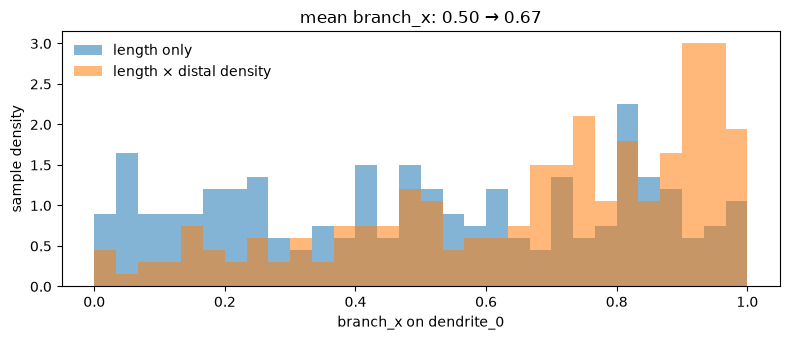

In [10]:
def distal_density(ctx):
    distance = metric.path_distance_from_soma(ctx)
    return u.math.exp(distance / (20.0 * u.um))


def distance_band_density(ctx):
    distance = metric.path_distance_from_soma(ctx)
    z = (distance - 60.0 * u.um) / (15.0 * u.um)
    return u.math.exp(-0.5 * z**2)


def thick_branch_density(ctx):
    radius = metric.radius(ctx)
    return (radius / (1.0 * u.um)) ** 2


def dendrite_type_density(ctx):
    return 3.0 if ctx.branch_type in {"basal_dendrite", "apical_dendrite"} else 1.0


one_dendrite = branch_in("name", "dendrite_0")
length_only = sample(
    one_dendrite, number=200, seed=11, measure="length",
).evaluate(goc_morphology)
distal_preference = sample(
    one_dendrite, number=200, seed=11, measure="length",
    density=distal_density,
).evaluate(goc_morphology)

fig, ax = plt.subplots(figsize=(8, 3.5))
bins = np.linspace(0.0, 1.0, 31)
ax.hist(length_only.branch_x, bins=bins, density=True, alpha=0.55, label="length only")
ax.hist(distal_preference.branch_x, bins=bins, density=True, alpha=0.55, label="length × distal density")
ax.set(
    xlabel="branch_x on dendrite_0", ylabel="sample density",
    title=f"mean branch_x: {length_only.branch_x.mean():.2f} → {distal_preference.branch_x.mean():.2f}",
)
ax.legend(frameon=False)
fig.tight_layout()

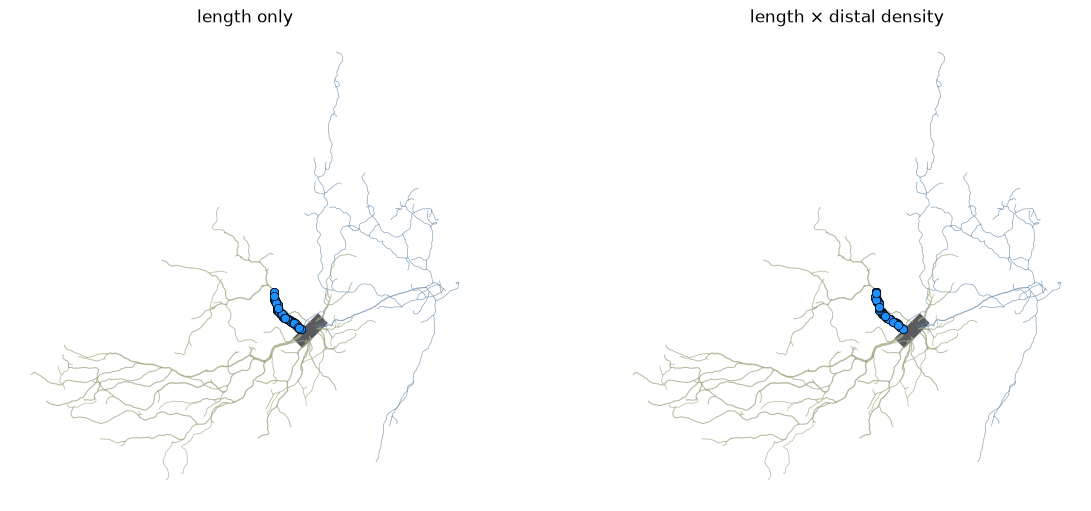

In [11]:
one_dendrite_mask = one_dendrite.evaluate(goc_morphology)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, locations, title in zip(
    axes,
    [length_only, distal_preference],
    ["length only", "length × distal density"],
):
    goc_morphology.vis2d(
        layout="projected", shape="line",
        region=one_dendrite_mask, locset=locations,
        ax=ax, show=False,
    )
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)


## 7. 将三维空间 density 限制到 morphology

设 morphology 上连续位置 $(b,x)$ 的三维坐标为 $\mathbf r(b,x)$，任意空间密度 $f_{3D}(\mathbf r)$ 都可以限制到 morphology 中心线：

$$\rho_{\mathrm{morph}}(b,x)=f_{3D}\!\left(\mathbf r(b,x)\right).$$

这不是先在自由三维空间采点、再投影到 morphology；采样候选点始终位于 region 上。`metric.position(ctx)` 只是把候选点映射到三维坐标，以便计算其权重。下面从真实 GoC 中选择 10 条空间分离的 dendrites，并用各向异性 Gaussian 偏好靠近 `dendrite_53` 末端的区域：

$$f_{3D}(\mathbf r)=\exp\left[-\frac12\sum_{i=1}^3\left(\frac{r_i-c_i}{\sigma_i}\right)^2\right].$$

In [12]:
spatial_branch_names = (
    "dendrite_0", "dendrite_12", "dendrite_14", "dendrite_18", "dendrite_32",
    "dendrite_51", "dendrite_52", "dendrite_53", "dendrite_54", "dendrite_60",
)
spatial_far_names = spatial_branch_names[5:]
spatial_region = branch_in("name", spatial_branch_names)
spatial_region_mask = spatial_region.evaluate(goc_morphology)
center = goc_morphology.branch(name="dendrite_53").points[-1]
scale = np.asarray([60.0, 50.0, 40.0]) * u.um


def spatial_density(ctx):
    z = (metric.position(ctx) - center) / scale
    return u.math.exp(-0.5 * u.math.sum(z**2, axis=-1))


unweighted_spatial = sample(
    spatial_region, number=200, seed=12, measure="length",
).evaluate(goc_morphology)
focused_spatial = sample(
    spatial_region, number=200, seed=12, measure="length",
    density=spatial_density,
).evaluate(goc_morphology)

far_branch_ids = np.asarray([
    goc_morphology.branch(name=name).index for name in spatial_far_names
])
fractions = pd.DataFrame({
    "sampling": ["length only", "length × spatial density"],
    "fraction on far dendrites": [
        np.mean(np.isin(unweighted_spatial.branch_id, far_branch_ids)),
        np.mean(np.isin(focused_spatial.branch_id, far_branch_ids)),
    ],
})
assert fractions.iloc[1, 1] > fractions.iloc[0, 1]
fractions

,sampling,fraction on far dendrites
0,length only,0.485
1,length × spatial density,1.000


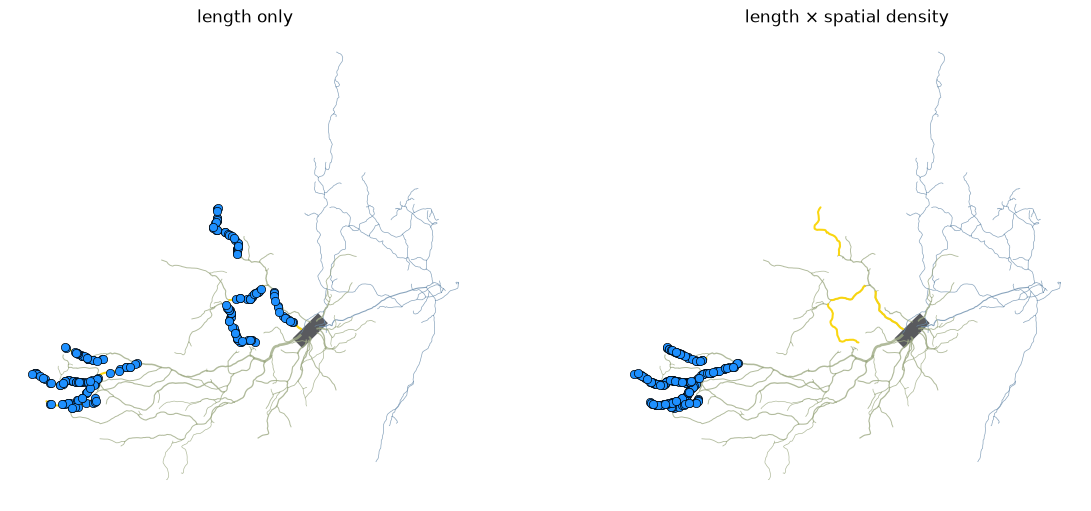

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, locations, title in zip(
    axes,
    [unweighted_spatial, focused_spatial],
    ["length only", "length × spatial density"],
):
    goc_morphology.vis2d(
        layout="projected", shape="line",
        region=spatial_region_mask,
        locset=locations, ax=ax, show=False,
    )
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)

### 同一组 region 与 locset 的三维显示

`vis3d(region=..., locset=...)` 与 2D 使用相同的 evaluated masks：region 显示为高亮管段，locset 显示为球形标记。每次调用各接受一个 region 和 locset；需要多个集合时，先组合表达式再 evaluate。GoC 的 ASC 带有完整 point geometry，因此可以直接使用 Plotly 交互式后端旋转和缩放。

In [14]:
figure_3d = goc_morphology.vis3d(
    backend="plotly",
    region=spatial_region_mask,
    locset=focused_spatial,
    show=False,
)
figure_3d.update_layout(title="GoC: length × spatial density")
figure_3d

## 总结

- `Synapse` 声明突触动力学，`place()` 创建 logical synapse instances。
- 位置既可广播为规则的 `(P, L)` 布局，也可用 ragged locset 为每个 cell 放置不同数量的突触。
- `cell.synapses` 及其切片返回 `SynapseView`；`.set()` 修改当前 view 命中的参数。
- `sample(region, number, seed, measure, density)` 可以直接作为 `place()` 的位置参数。
- `metric` 读取连续候选点的几何量；density 将这些量组合成非负权重，包括三维空间偏好。
- `vis2d` 和 `vis3d` 共用 evaluated region/locset；3D 将它们显示为高亮管段和球形标记。
- 连续位置映射到同一个 CV 时仍然是独立突触。
- `weight` 和 `delay` 属于 Connection，而不是 Synapse；它们将在 Connection 教程中介绍。